In [1]:
%config InlineBackend.figure_format = 'svg'

# Qiskit References

- Qiskit Guides: https://quantum.cloud.ibm.com/docs/en/guides
- Qiskit API Docs: https://quantum.cloud.ibm.com/docs/en/api/qiskit
- IBM Quantum Platform Classic: https://quantum.ibm.com/
- IBM Quantum Platform Classic Setup: https://docs.quantum.ibm.com/guides/setup-channel

In [2]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import networkx as nx
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister, Parameter
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp, Statevector, DensityMatrix
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import timeline_drawer
from scipy.optimize import minimize

Below are an ideal sampler and estimator, for use in noiseless simulations.

In [3]:
from qiskit_aer.primitives import SamplerV2 as AerSampler, EstimatorV2 as AerEstimator
ideal_sampler = AerSampler()
ideal_estimator = AerEstimator()

To access real QPUs, such as IBM Kyiv below, you must set up an account on [IBM Quantum Platform Classic](https://docs.quantum.ibm.com/guides/setup-channel) or [IBM Cloud Account](https://quantum.cloud.ibm.com/docs/en/guides/cloud-setup).

In [4]:
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService()
# ibm_kyiv = service.backend("ibm_kyiv")

Below are a sampler and estimator for noisy simulation on IBM Kyiv, as well as a pass manager for that backend.

In [5]:
# ibm_kyiv_aer_sampler = AerSampler.from_backend(ibm_kyiv)
# ibm_kyiv_aer_estimator = AerEstimator.from_backend(ibm_kyiv)
# ibm_kyiv_pm = generate_preset_pass_manager(optimization_level=3, backend=ibm_kyiv)

Below are a sampler and estimator for runtime execution on IBM Kyiv. 

In [6]:
# from qiskit_ibm_runtime import SamplerV2 as RuntimeSampler, EstimatorV2 as RuntimeEstimator
# ibm_kyiv_runtime_sampler = AerSampler.from_backend(ibm_kyiv)
# ibm_kyiv_runtime_estimator = AerEstimator.from_backend(ibm_kyiv)

Some utility functions:

In [7]:
from collections.abc import Sequence
from itertools import product

def bitstrings(num_bits: int) -> Sequence[str]:
    """The sequence of all bitstrings for the given number of bits."""
    return tuple(map("".join, product("01", repeat=num_bits)))

def paulistrings(num_qubits: int) -> Sequence[str]:
    """The sequence of all Paulistrings for the given number of qubits."""
    return tuple(map("".join, product("IXYZ", repeat=num_qubits)))

In [8]:
from collections.abc import Sequence 

def _balanced_cx_tree(qubits):
    cs, ts = [], []
    if len(qubits) <= 1:
        return cs, ts
    if len(qubits) % 2 == 1:
        cs.append(qubits[-1]); ts.append(qubits[-2])
        qubits = qubits[:-1]
    cs.extend(qubits[::2]); ts.extend(qubits[1::2])
    _cs, _ts = _balanced_cx_tree(qubits[1::2])
    cs.extend(_cs); ts.extend(_ts)
    return cs, ts

def apply_phase_gadget(circ: QuantumCircuit, legs: Sequence[int], angle: float | Parameter) -> None:
    if not legs:
        return
    if len(legs) == 1:
        circ.rz(angle, legs[0])
        return
    if len(legs) == 2:
        circ.rzz(angle, legs[0], legs[1])
        return
    cs, ts = _balanced_cx_tree(legs)
    circ.cx(cs[:-1], ts[:-1])
    circ.rzz(angle, cs[-1], ts[-1])
    circ.cx(cs[-2::-1], ts[-2::-1])

def apply_pauli_gadget(circ: QuantumCircuit, pauli: Pauli, angle: float | Parameter) -> None:
    _paulis = str(pauli)[::-1]
    for q, p in enumerate(_paulis):
        if p == "X":
            circ.h(q)
        elif p == "Y":
            circ.sx(q)
    apply_phase_gadget(circ, [q for q, p in enumerate(_paulis) if p != "I"], angle)
    for q, p in enumerate(_paulis):
        if p == "X":
            circ.h(q)
        elif p == "Y":
            circ.sxdg(q)

In [9]:
from collections.abc import Iterator
from itertools import chain, combinations

def iter_powerset[T](s: Sequence[T]) -> Iterator[tuple[T, ...]]:
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

def cost_to_problem_hamiltonian(cost: dict[str, float]) -> SparsePauliOp:
    assert cost
    num_qubits = len(next(iter(cost.keys())))
    assert all(len(bs) == num_qubits for bs in cost.keys())
    assert all(all(b in "01" for b in bs) for bs in cost.keys())
    return SparsePauliOp.from_sparse_list([
        ("Z"*len(legs), legs, coeff)
        for legs in iter_powerset(range(num_qubits))
        if (coeff := sum(c*(-1)**sum(int(bs[num_qubits-1-q]) for q in legs) for bs, c in cost.items())/(2**num_qubits)) != 0
    ], num_qubits=num_qubits)

In [10]:
def is_problem_hamiltonian(H: SparsePauliOp) -> bool:
    return all(
        all(c in "IZ" for c in str(p))
        for p in H.paulis
    ) and np.allclose(H.coeffs.imag, 0)

def is_ising_hamiltonian(H: SparsePauliOp) -> bool:
    return is_problem_hamiltonian(H) and all(
        str(p).count("Z") <= 2 for p in H.paulis        
    )

def eval_problem_hamiltonian(H: SparsePauliOp, bs: str) -> float:
    assert is_problem_hamiltonian(H)
    assert all(b in "01" for b in bs)
    val = 0.0
    for paulistr, coeff in zip(H.paulis, H.coeffs.real):
        val += coeff*(-1)**sum(1 if b == "1" and p == "Z" else 0 for b, p in zip(bs, str(paulistr)))
    return float(val)

In [11]:
def qaoa_ansatz(H: SparsePauliOp, num_layers: int = 1) -> QuantumCircuit:
    assert is_problem_hamiltonian(H)
    assert num_layers >= 1
    num_qubits = H.num_qubits
    qubits = range(num_qubits)
    circ = QuantumCircuit(num_qubits) # |0...0>
    circ.h(qubits) # |+...+>
    circ.barrier()
    for l in range(num_layers):
        beta = Parameter(f"β_{l}")
        gamma = Parameter(f"γ_{l}")
        for pauli, coeff in zip(H.paulis, H.coeffs):
            legs = [q for q, p in enumerate(str(pauli)[::-1]) if p != "I"] # p is either I or Z
            apply_phase_gadget(circ, legs, coeff*beta)
        circ.barrier()
        circ.rx(gamma, qubits)
        circ.barrier()
    return circ

from typing import Any, TypeAlias
from collections.abc import Callable

FloatArray: TypeAlias = np.ndarray[Any, np.dtype[np.floating[Any]]]
CostFun: TypeAlias = Callable[[FloatArray], float]

def qaoa_cost_fun(H: SparsePauliOp, num_layers: int = 1, estimator=ideal_estimator) -> CostFun:
    ansatz = qaoa_ansatz(H, num_layers)
    def cost_fun(param_vals: FloatArray) -> float:
        result = estimator.run([(ansatz, H, param_vals)]).result()
        return float(result[0].data.evs)
    return cost_fun

# Assignment

## Task 1

In [12]:
from typing import Callable
from inspect import signature

In [13]:
def cost_func_to_dense_problem_hamiltonian(cost_function: Callable, arity: int) -> SparsePauliOp:
    return cost_to_problem_hamiltonian({
        ''.join(map(str, bit_tuple[::-1])): cost_function(*bit_tuple)
        for bit_tuple in product([0, 1], repeat=arity)
    })

def dense_to_sparse(problem_hamiltonian: SparsePauliOp, indices: list[int], num_qubits: int) -> SparsePauliOp:
    assert max(indices) < num_qubits, "Can't specify an index larger than the no. of qubits we have"
    return SparsePauliOp.from_sparse_list([
        (str(pauli)[::-1], indices, coeff)
        for pauli, coeff in zip(problem_hamiltonian.paulis, problem_hamiltonian.coeffs.real)
    ], num_qubits)

def cost_func_to_sparse_problem_hamiltonian(cost_function: Callable, indices: list[int], num_qubits: int) -> SparsePauliOp:
    arity = len(signature(cost_function).parameters)
    assert arity==len(indices), "Cost function must take the same no. of args as the no. of bitstring indices we specify"
    dense_ph = cost_func_to_dense_problem_hamiltonian(cost_function, arity)
    return dense_to_sparse(dense_ph, indices, num_qubits)

def eval_over_bitstrings(problem_hamiltonian: SparsePauliOp, num_qubits: int):
    for bs in bitstrings(num_qubits):
        cost = eval_problem_hamiltonian(problem_hamiltonian, bs)
        # For concision when checking we'll just inspect bitstrings that induce the ground state.
        if cost == 0.0:
            # Costs are returned attached to a reversed bitstring, this is easier to read
            # if reversed back again.
            print(f"{bs[::-1]} has cost {cost}")

In [14]:
def and_hamiltonian(i, j, k, num_qubits) -> SparsePauliOp:
    return cost_func_to_sparse_problem_hamiltonian(
        lambda bi, bj, bk: (bi and bj) ^ bk, [i, j, k], num_qubits
    )

def or_hamiltonian(i, j, k, num_qubits) -> SparsePauliOp:
    return cost_func_to_sparse_problem_hamiltonian(
        lambda bi, bj, bk: (bi or bj) ^ bk, [i, j, k], num_qubits
    )

def xor_hamiltonian(i, j, k, num_qubits) -> SparsePauliOp:
    return cost_func_to_sparse_problem_hamiltonian(
        lambda bi, bj, bk: (bi ^ bj) ^ bk, [i, j, k], num_qubits
    )

def not_hamiltonian(i, j, num_qubits) -> SparsePauliOp:
    return cost_func_to_sparse_problem_hamiltonian(
        lambda bi, bj: (not bi) ^ bj, [i, j], num_qubits
    )

def const0_hamiltonian(i, num_qubits) -> SparsePauliOp:
    return cost_func_to_sparse_problem_hamiltonian(
        lambda bi: 0 ^ bi, [i], num_qubits
    )

def const1_hamiltonian(i, num_qubits) -> SparsePauliOp:
    return cost_func_to_sparse_problem_hamiltonian(
        lambda bi: 1 ^ bi, [i], num_qubits
    )

## Task 2

In [15]:
def half_adder_hamiltonian(i, j, k, l, num_qubits) -> SparsePauliOp:
    carry_hamiltonian = and_hamiltonian(i, j, k, num_qubits)
    sum_hamiltonian = xor_hamiltonian(i, j, l, num_qubits)
    return sum_hamiltonian + carry_hamiltonian

eval_over_bitstrings(half_adder_hamiltonian(0,1,2,3, num_qubits=4), 4)

0000 has cost 0.0
1110 has cost 0.0
1001 has cost 0.0
0101 has cost 0.0


In [16]:
def constrained_half_adder(i, j, num_qubits) -> SparsePauliOp:
    # We need to provide 2 unspecified qubit indices to half_adder_hamiltonian()
    # Doesn't matter which since they're getting constant'd, but they mustn't be i or j!
    unused_indices = [x for x in range(num_qubits) if x not in [i,j]]
    k, l = unused_indices[0], unused_indices[1]
    ha_hamiltonian = half_adder_hamiltonian(i, j, k, l, num_qubits)
    return ha_hamiltonian + const1_hamiltonian(k, num_qubits) + const0_hamiltonian(l, num_qubits)

eval_over_bitstrings(constrained_half_adder(0,1, num_qubits=4), 4)

1110 has cost 0.0


In [17]:
H = constrained_half_adder(0,1, num_qubits=4)

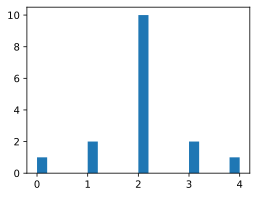

Minimum energy sol'ns for this Hamiltonian: ['1110']


In [18]:
rng = np.random.default_rng(0)
num_layers = 1
init_param_vals = rng.uniform(-1e-2, 1e-2, size=2*num_layers)
cost_fun = qaoa_cost_fun(H, num_layers)
res = minimize(cost_fun, init_param_vals)

circ = qaoa_ansatz(H, num_layers)
circ.measure_all()
result = ideal_sampler.run([(circ, res.x, 1000)]).result()
counts = result[0].data[circ.cregs[0].name].get_counts()
sampled_bitstrings = sorted(counts.keys())
sampled_energies = [eval_problem_hamiltonian(H, bs) for bs in sampled_bitstrings]
min_sampled_energy = min(sampled_energies)
soln_bitstrings = [
    bs
    for bs, e in zip(sampled_bitstrings, sampled_energies)
    if e == min_sampled_energy
]
plt.figure(figsize=(4, 3))
plt.hist(sampled_energies, bins=20)
plt.show()
print(f"Minimum energy sol'ns for this Hamiltonian: {[sol[::-1] for sol in  soln_bitstrings]}")